In [4]:
# imports

import sys
from pathlib import Path

# Add the parent directory to the path to import src module
sys.path.append(str(Path().resolve().parent))

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.models import SegmentationModel
from src.datasets import ISICSegmentationDataset
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# recreate same val split

IMG_SIZE = 256

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

dataset = ISICSegmentationDataset(
    "../data/raw/ISIC/ISIC2018_Task1-2_Training_Input",
    "../data/raw/ISIC/ISIC2018_Task1_Training_GroundTruth",
    transform
)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

_, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(val_dataset, batch_size=8)

In [6]:
# load best model

model = SegmentationModel(pretrained=False)
model.load_state_dict(
    torch.load("../data/processed/best_segmentation_model.pth", map_location=DEVICE)
)
model = model.to(DEVICE)
model.eval()

/tmp/ipykernel_145591/65299044.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../data/processed/best_segmentation_model.pth", map_location=DEVICE)


SegmentationModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [7]:
# metric functions

def dice_score(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    return (2. * intersection) / (union + 1e-8)


def iou_score(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum()
    union = (preds + targets).clamp(0, 1).sum()

    return intersection / (union + 1e-8)

In [8]:
# compute validation metrics

dice_scores = []
iou_scores = []

with torch.no_grad():
    for images, masks in tqdm(val_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)

        dice = dice_score(preds, masks)
        iou = iou_score(preds, masks)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

print("Mean Dice:", np.mean(dice_scores))
print("Mean IoU:", np.mean(iou_scores))

100%|██████████| 33/33 [00:25<00:00,  1.32it/s]

Mean Dice: 0.9032668832576636
Mean IoU: 0.8253461176698859


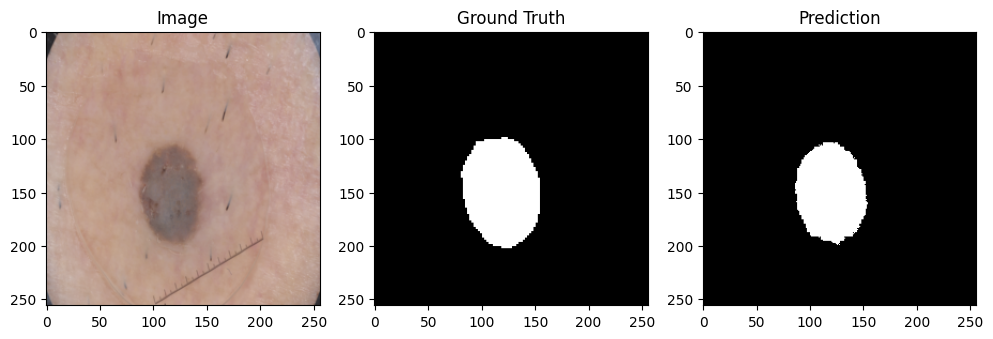

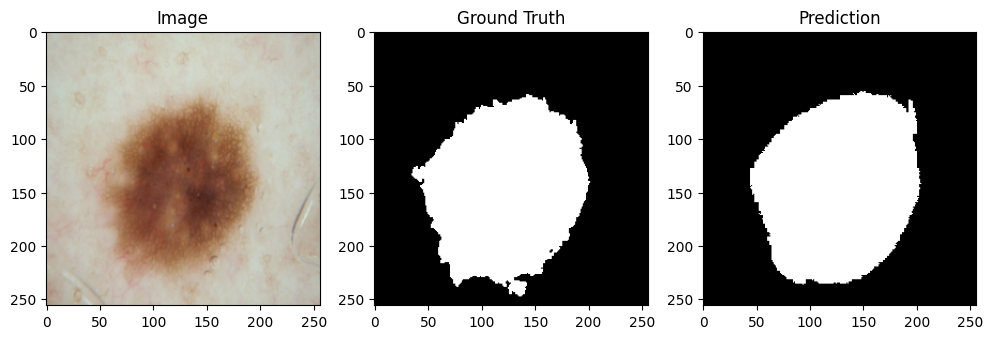

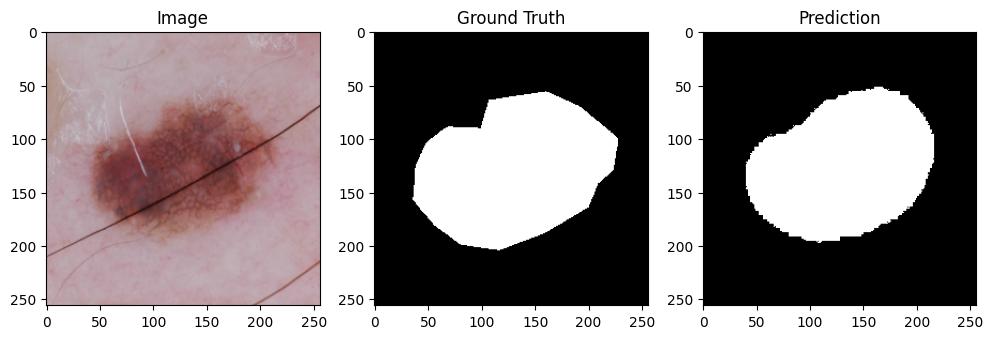

In [9]:
# visualise predictions

def visualize_prediction(idx=0):
    image, mask = val_dataset[idx]

    model.eval()
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(DEVICE))
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    image = image.permute(1, 2, 0).numpy()
    mask = mask.squeeze().numpy()
    pred = pred.squeeze().cpu().numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")

    plt.show()


visualize_prediction(10)
visualize_prediction(50)
visualize_prediction(120)

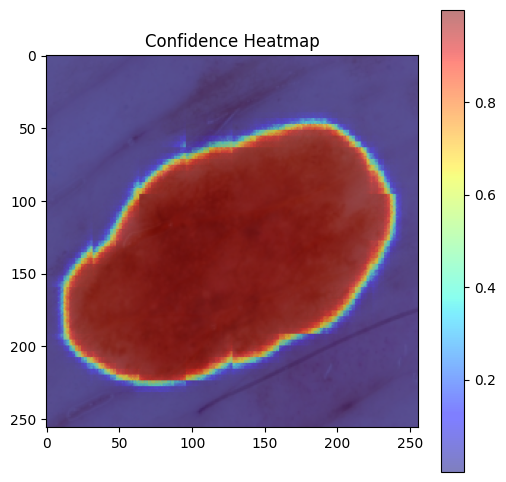

In [10]:
# overlay heatmap

def visualize_heatmap(idx=0):
    image, mask = val_dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(DEVICE))
        prob = torch.sigmoid(pred).squeeze().cpu().numpy()

    image = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(prob, cmap="jet", alpha=0.5)
    plt.title("Confidence Heatmap")
    plt.colorbar()
    plt.show()


visualize_heatmap(20)

In [12]:
# identify worst case

worst_cases = []

with torch.no_grad():
    for idx in tqdm(range(len(val_dataset))):
        image, mask = val_dataset[idx]
        image = image.unsqueeze(0).to(DEVICE)
        mask = mask.unsqueeze(0).to(DEVICE)

        pred = model(image)

        dice = dice_score(pred, mask)
        worst_cases.append((dice.item(), idx))

worst_cases.sort()

print("Worst Dice:", worst_cases[:5])

100%|██████████| 260/260 [00:24<00:00, 10.55it/s]

Worst Dice: [(0.18643119931221008, 204), (0.2450224757194519, 213), (0.41069766879081726, 248), (0.42661333084106445, 155), (0.4272070825099945, 70)]


In [13]:
import pandas as pd
from pathlib import Path

results_path = Path("../results/experiments_segmentation.csv")

experiment_row = {
    "model_name": "resnet34_segmentation",
    "backbone": "resnet34_imagenet",
    "img_size": 256,
    "loss_type": "BCE+Dice",
    "epochs_trained": 12,
    "best_val_loss": 0.2436,
    "mean_dice": 0.9033,
    "mean_iou": 0.8253,
    "batch_size": 8,
    "learning_rate": 1e-4,
    "split_seed": 42
}

df = pd.DataFrame([experiment_row])

if results_path.exists():
    df.to_csv(results_path, mode="a", header=False, index=False)
else:
    df.to_csv(results_path, index=False)

print("Segmentation experiment logged successfully.")

Segmentation experiment logged successfully.
